In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import datetime
import csv

# Configuration
RESULTS_DIR = Path("../results")


In [2]:
# data_path = [("measurement/psd/concat_phase_smooth_2026-02-05 22:06:15_2026-02-05 22:06:29.npy"),
# "measurement/psd/concat_phase_smooth_2026-02-05 22:12:16_2026-02-05 22:12:31.npy",
# "measurement/psd/concat_phase_smooth_2026-02-05 22:12:52_2026-02-05 22:13:06.npy"]
# data_path = [("measurement/psd/concat_phase_smooth_2026-02-25 00:59:27_2026-02-25 00:59:45.npy"),
# "measurement/psd/concat_phase_smooth_2026-02-25 00:59:48_2026-02-25 01:00:02.npy"]
data_path = ["measurement/psd/concat_phase_smooth_2026-02-25 01:01:09_2026-02-25 06:05:51.npy"]

# time_path = "measurement/psd/concat_time_full_swing_2026-02-05 22:12:16_2026-02-05 22:12:31.npy"
# time_path = "measurement/psd/concat_time_full_swing_2026-02-25 00:59:48_2026-02-25 01:00:02.npy"
time_path = "measurement/psd/concat_time_full_swing_2026-02-25 01:01:09_2026-02-25 06:05:51.npy"


# psd_name = Path("psd/psd_average_old_fast.npy")
# freqs_name = Path("psd/freqs_average_old_fast.npy")
# times_name = Path("psd/times_average_old_fast.npy")

# psd_name = Path("psd/psd_average_new_fast.npy")
# freqs_name = Path("psd/freqs_average_new_fast.npy")
# times_name = Path("psd/times_average_new_fast.npy")

psd_name = Path("psd/psd_average_new_slow.npy")
freqs_name = Path("psd/freqs_average_new_slow.npy")
times_name = Path("psd/times_average_new_slow.npy")


In [3]:
data_list = [np.load(Path("..") / data_path[i]) for i in range(len(data_path))]

time_array = np.load(Path("..") / time_path)

In [4]:
len(data_list),len(data_list[0])

(1, 14768)

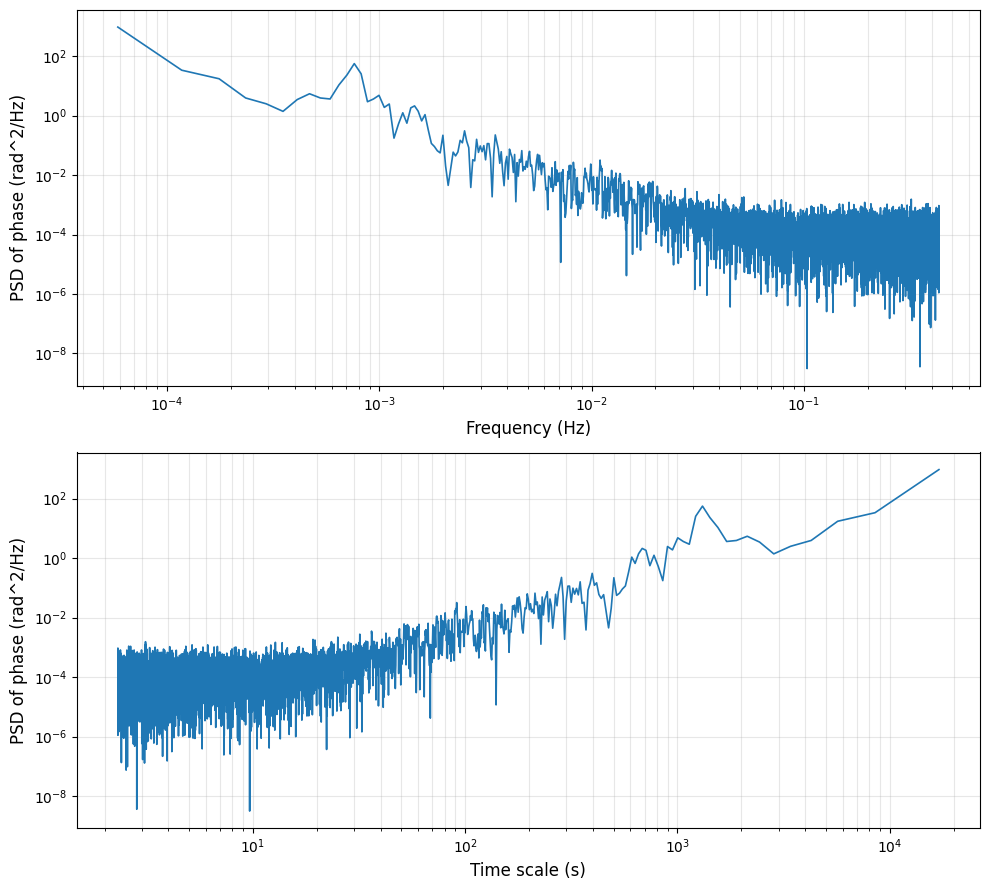

Estimated sampling rate from timestamps: 0.866 Hz
Frequency span: 0.000059 Hz to 0.433 Hz


In [5]:
psd_list = []
for i in range(len(data_list)):
    t_phase = np.asarray(time_array, dtype=float)

    # concat_phase is stored in degrees; unwrap in radians to avoid 360 deg jumps
    phase_deg = np.asarray(data_list[i], dtype=float)
    phase_rad = np.deg2rad(phase_deg)

    # Build a uniform time grid for FFT-based PSD (robust to timing jitter)
    dt_median = np.median(np.diff(t_phase))
    if dt_median <= 0:
        raise ValueError("Non-positive time step detected in concat_time_full_swing")

    fs = 1.0 / dt_median
    t_uniform = np.arange(t_phase[0], t_phase[-1] + 0.5 * dt_median, dt_median)



    
    # phase_uniform = np.interp(t_uniform, t_phase, phase_rad_unwrapped) Skipping this step

    # Detrend (remove DC) before PSD
    phase_zero_mean = phase_rad - np.mean(phase_rad)
    phase_hamming = phase_zero_mean * np.hamming(len(phase_zero_mean))
    n = len(phase_hamming)

    # One-sided PSD via rFFT; units: rad^2/Hz
    fft_vals = np.fft.rfft(phase_hamming)
    freqs = np.fft.rfftfreq(n, d=dt_median)
    psd = (np.abs(fft_vals) ** 2) / (fs * n)
    if n > 1:
        psd[1:-1] *= 2.0

    # Plot both views in one figure: frequency and time scale
    valid = freqs > 0
    time_scales = 1.0 / freqs[valid]
    sort_idx = np.argsort(time_scales)

    fig, (ax_freq, ax_time) = plt.subplots(2, 1, figsize=(10, 9))

    ax_freq.loglog(freqs[valid], psd[valid], linewidth=1.2)
    ax_freq.set_xlabel('Frequency (Hz)', fontsize=12)
    ax_freq.set_ylabel('PSD of phase (rad^2/Hz)', fontsize=12)
    # ax_freq.set_title(f'Phase PSD vs Frequency: {start_str} to {end_str}', fontsize=14)
    ax_freq.grid(True, which='both', alpha=0.3)

    ax_time.loglog(time_scales[sort_idx], psd[valid][sort_idx], linewidth=1.2)
    ax_time.set_xlabel('Time scale (s)', fontsize=12)
    ax_time.set_ylabel('PSD of phase (rad^2/Hz)', fontsize=12)
    # ax_time.set_title(f'Phase PSD vs Time Scale: {start_str} to {end_str}', fontsize=14)
    ax_time.grid(True, which='both', alpha=0.3)

    plt.tight_layout()
    plt.show()
    psd_list.append(psd)

    print(f"Estimated sampling rate from timestamps: {fs:.3f} Hz")
    print(f"Frequency span: {freqs[1]:.6f} Hz to {freqs[-1]:.3f} Hz")

In [6]:
psd_list[0][0]

np.float64(478.1039222463176)

In [7]:
freqs

array([0.00000000e+00, 5.86392070e-05, 1.17278414e-04, ...,
       4.32874626e-01, 4.32933266e-01, 4.32991905e-01], shape=(7385,))

In [8]:
psd_average = 0
for i in range(len(psd_list)):
    psd_average += psd_list[i]
psd_average = psd_average/len(psd_list)


np.save(psd_name, psd_average[valid])
np.save(freqs_name, freqs[valid])
np.save(times_name, time_scales[sort_idx])





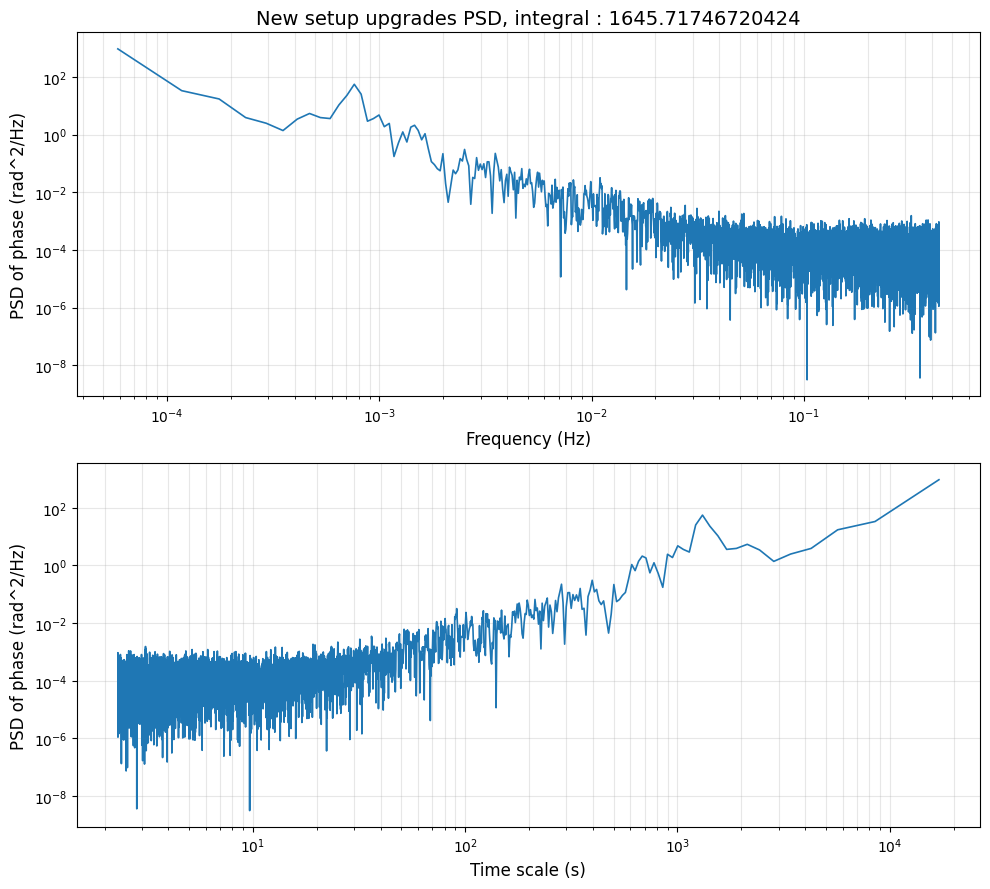

In [9]:
fig, (ax_freq, ax_time) = plt.subplots(2, 1, figsize=(10, 9))

ax_freq.loglog(freqs[valid], psd_average[valid], linewidth=1.2)
ax_freq.set_xlabel('Frequency (Hz)', fontsize=12)
ax_freq.set_ylabel('PSD of phase (rad^2/Hz)', fontsize=12)
ax_freq.set_title(f'New setup upgrades PSD, integral : {sum(psd_average)}', fontsize=14)
ax_freq.grid(True, which='both', alpha=0.3)

ax_time.loglog(time_scales[sort_idx], psd[valid][sort_idx], linewidth=1.2)
ax_time.set_xlabel('Time scale (s)', fontsize=12)
ax_time.set_ylabel('PSD of phase (rad^2/Hz)', fontsize=12)
# ax_time.set_title(f'Phase PSD vs Time Scale: {start_str} to {end_str}', fontsize=14)
ax_time.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()